# 08-1. CVAE (Conditional VAE) — PyTorch

VAE에 레이블 조건(action 종류)을 추가해 원하는 동작의 이미지를 생성할 수 있도록 합니다.

| 구분 | VAE | CVAE |
|------|-----|------|
| 인코더 입력 | 이미지 | 이미지 + 레이블 |
| 디코더 입력 | z | z + 레이블 |
| 생성 제어 | 불가 | 레이블로 동작 지정 가능 |

## 1. 환경 설정

In [1]:
import os, json, random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split

# fix working directory
_root = Path(os.path.abspath(''))
for _p in [_root] + list(_root.parents):
    if (_p / 'dataset' / 'processed').exists():
        os.chdir(_p); break
print(f'CWD: {Path.cwd()}')

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

CKPT_DIR = Path('checkpoints_cvae_pt')
CKPT_DIR.mkdir(exist_ok=True)

ACTIONS     = ['walk', 'idle', 'run', 'slash', 'shoot', 'thrust', 'jump', 'sit', 'spellcast']
NUM_CLASSES = len(ACTIONS) + 1   # + 'other'
LABEL_NAMES = ACTIONS + ['other']

CFG = {
    'latent_dim'   : 128,
    'base_channels': 32,
    'channels'     : 4,
    'num_classes'  : NUM_CLASSES,
    'epochs'       : 100,
    'batch_size'   : 128,
    'lr'           : 1e-3,
    'beta'         : 1.0,
    'patience'     : 10,
}

with open(CKPT_DIR / 'config.json', 'w') as f:
    json.dump(CFG, f, indent=2)

LATENT_DIM = CFG['latent_dim']
BASE_CH    = CFG['base_channels']
CHANNELS   = CFG['channels']
EPOCHS     = CFG['epochs']
BATCH_SIZE = CFG['batch_size']
LR         = CFG['lr']
BETA       = CFG['beta']
PATIENCE   = CFG['patience']
print('CFG:', CFG)

CWD: /Users/gomuseo/Desktop/Python/vae_test
Device: mps
CFG: {'latent_dim': 128, 'base_channels': 32, 'channels': 4, 'num_classes': 10, 'epochs': 100, 'batch_size': 128, 'lr': 0.001, 'beta': 1.0, 'patience': 10}


## 2. 레이블 정의

In [2]:
BODY_DIR  = Path('dataset/processed/body')
all_paths = sorted(BODY_DIR.glob('*.png'))

def get_label(path):
    name = Path(path).name
    for i, kw in enumerate(ACTIONS):
        if kw in name:
            return i
    return len(ACTIONS)  # 'other'

all_labels = [get_label(p) for p in all_paths]
dist = Counter(LABEL_NAMES[l] for l in all_labels)
print('Label distribution:')
for name, cnt in sorted(dist.items(), key=lambda x: -x[1]):
    print(f'  {name:>12}: {cnt}')

Label distribution:
         slash: 1032
          walk: 864
          jump: 480
         shoot: 416
           run: 320
        thrust: 320
         other: 288
           sit: 288
     spellcast: 280
          idle: 256


## 3. 데이터셋 준비

In [3]:
class SpriteDataset(Dataset):
    def __init__(self, paths, labels, num_classes):
        self.paths       = paths
        self.labels      = labels
        self.num_classes = num_classes
        self.transform   = transforms.ToTensor()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = self.transform(Image.open(self.paths[idx]).convert('RGBA'))
        c   = F.one_hot(torch.tensor(self.labels[idx]), self.num_classes).float()
        return img, c


str_paths = [str(p) for p in all_paths]
tr_paths, vl_paths, tr_labels, vl_labels = train_test_split(
    str_paths, all_labels, test_size=0.1, random_state=42, stratify=all_labels
)
print(f'Train: {len(tr_paths)}  Val: {len(vl_paths)}')

train_ds = SpriteDataset(tr_paths, tr_labels, NUM_CLASSES)
val_ds   = SpriteDataset(vl_paths, vl_labels, NUM_CLASSES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, drop_last=False)
print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

Train: 4089  Val: 455
Train batches: 31  Val batches: 4


## 4. CVAE 모델

인코더와 디코더 모두 특징 벡터에 one-hot 레이블을 concat해 조건을 주입합니다.

In [4]:
class CVAEEncoder(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        layers, in_ch, ch = [], channels, base_ch
        for _ in range(4):
            layers += [nn.Conv2d(in_ch, ch, 4, stride=2, padding=1),
                       nn.BatchNorm2d(ch, momentum=0.1),
                       nn.LeakyReLU(0.2)]
            in_ch = ch; ch *= 2
        self.conv  = nn.Sequential(*layers)
        flat_dim   = (base_ch * 8) * 4 * 4
        self.fc_mu = nn.Linear(flat_dim + num_classes, latent_dim)
        self.fc_lv = nn.Linear(flat_dim + num_classes, latent_dim)

    def forward(self, x, c):
        h = self.conv(x).flatten(1)
        h = torch.cat([h, c], dim=-1)
        return self.fc_mu(h), self.fc_lv(h)


class CVAEDecoder(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        self.start_ch = base_ch * 8
        self.fc       = nn.Linear(latent_dim + num_classes, self.start_ch * 4 * 4)
        layers, in_ch = [], self.start_ch
        for i, out_ch in enumerate([base_ch*4, base_ch*2, base_ch, channels]):
            layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1))
            if i < 3:
                layers += [nn.BatchNorm2d(out_ch, momentum=0.1), nn.ReLU()]
            else:
                layers.append(nn.Sigmoid())
            in_ch = out_ch
        self.deconv = nn.Sequential(*layers)

    def forward(self, z, c):
        h = self.fc(torch.cat([z, c], dim=-1))
        return self.deconv(h.view(-1, self.start_ch, 4, 4))


class CVAE(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        self.encoder = CVAEEncoder(num_classes, base_ch, latent_dim, channels)
        self.decoder = CVAEDecoder(num_classes, base_ch, latent_dim, channels)

    def forward(self, x, c):
        mu, lv = self.encoder(x, c)
        z      = mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
        return self.decoder(z, c), mu, lv


model = CVAE(NUM_CLASSES, BASE_CH, LATENT_DIM, CHANNELS).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')

Parameters: 3,003,204


## 5. 손실 함수 & 학습 준비

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)


def compute_loss(recon, x, mu, lv, beta):
    batch      = x.size(0)
    recon_loss = F.mse_loss(recon, x, reduction='sum') / batch
    kl_loss    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / batch
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


print('Optimizer and loss ready.')

Optimizer and loss ready.


## 6. 학습

In [6]:
history = {'loss': [], 'val_loss': [], 'recon': [], 'kl': []}
best_val    = float('inf')
patience_cnt = 0

for epoch in range(EPOCHS):
    # train
    model.train()
    tr_loss = tr_recon = tr_kl = 0.0
    for x, c in train_loader:
        x, c = x.to(DEVICE), c.to(DEVICE)
        recon, mu, lv = model(x, c)
        loss, r, k = compute_loss(recon, x, mu, lv, BETA)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tr_loss += loss.item(); tr_recon += r.item(); tr_kl += k.item()
    n = len(train_loader)
    tr_loss /= n; tr_recon /= n; tr_kl /= n

    # val
    model.eval()
    vl_loss = 0.0
    with torch.no_grad():
        for x, c in val_loader:
            x, c = x.to(DEVICE), c.to(DEVICE)
            recon, mu, lv = model(x, c)
            loss, _, _ = compute_loss(recon, x, mu, lv, BETA)
            vl_loss += loss.item()
    vl_loss /= max(len(val_loader), 1)

    scheduler.step()

    history['loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['recon'].append(tr_recon)
    history['kl'].append(tr_kl)

    print(f'Epoch {epoch+1:>3}/{EPOCHS}  '
          f'loss={tr_loss:.2f}  recon={tr_recon:.2f}  kl={tr_kl:.2f}  '
          f'val_loss={vl_loss:.2f}  lr={scheduler.get_last_lr()[0]:.6f}')

    if vl_loss < best_val:
        best_val = vl_loss
        patience_cnt = 0
        torch.save(model.state_dict(), CKPT_DIR / 'best.pt')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

model.load_state_dict(torch.load(CKPT_DIR / 'best.pt', map_location=DEVICE))
print(f'\nBest val_loss: {best_val:.4f}')

Epoch   1/100  loss=2030.80  recon=2004.78  kl=26.02  val_loss=822.05  lr=0.001000


Epoch   2/100  loss=534.25  recon=509.41  kl=24.84  val_loss=390.52  lr=0.000999


Epoch   3/100  loss=335.26  recon=312.41  kl=22.85  val_loss=292.58  lr=0.000998


Epoch   4/100  loss=271.41  recon=245.31  kl=26.10  val_loss=251.24  lr=0.000996


Epoch   5/100  loss=234.14  recon=206.10  kl=28.04  val_loss=224.75  lr=0.000994


...

Epoch  96/100  loss=56.98  recon=33.37  kl=23.61  val_loss=61.78  lr=0.000014


Epoch  97/100  loss=57.01  recon=33.44  kl=23.57  val_loss=62.08  lr=0.000012


Epoch  98/100  loss=56.94  recon=33.29  kl=23.65  val_loss=61.87  lr=0.000011


Epoch  99/100  loss=56.92  recon=33.39  kl=23.53  val_loss=61.69  lr=0.000010


Epoch 100/100  loss=56.90  recon=33.40  kl=23.49  val_loss=61.92  lr=0.000010

Best val_loss: 61.5379


## 7. 학습 곡선

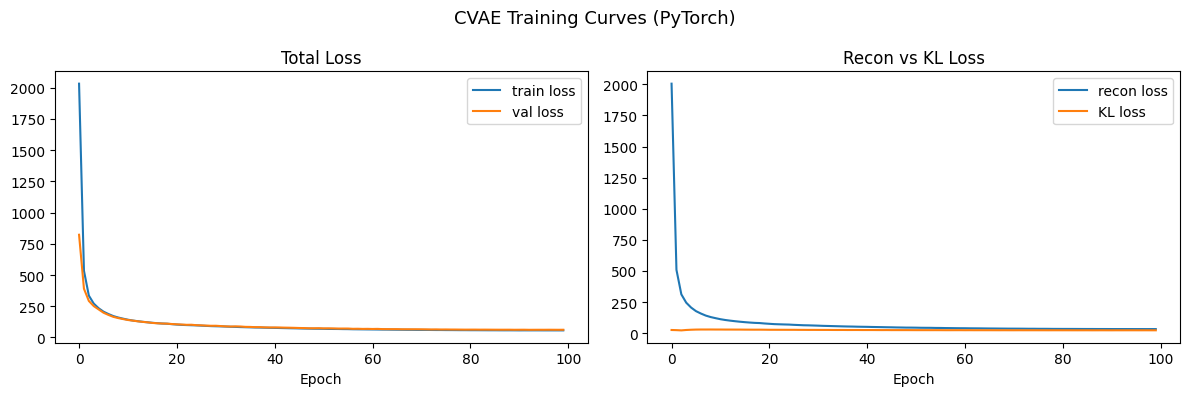

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['loss'],     label='train loss')
axes[0].plot(history['val_loss'], label='val loss')
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['recon'], label='recon loss')
axes[1].plot(history['kl'],    label='KL loss')
axes[1].set_title('Recon vs KL Loss'); axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.suptitle('CVAE Training Curves (PyTorch)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. 복원 결과 확인

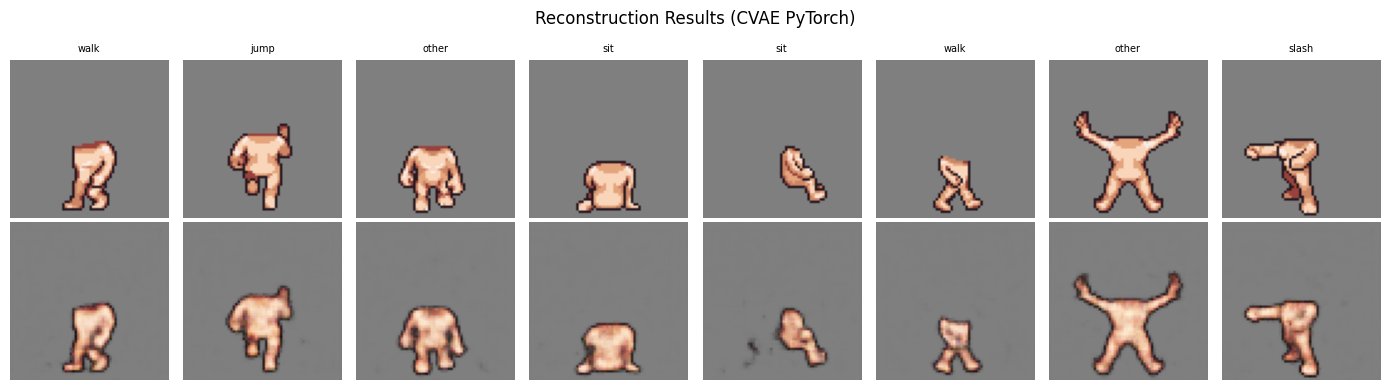

In [8]:
def composite(t):
    t = np.array(t)
    rgb, a = t[..., :3], t[..., 3:4]
    return rgb * a + np.ones_like(rgb) * 0.5 * (1 - a)


model.eval()
sample_x, sample_c = next(iter(val_loader))
sample_x = sample_x[:8].to(DEVICE)
sample_c = sample_c[:8].to(DEVICE)

with torch.no_grad():
    recon, _, _ = model(sample_x, sample_c)

sample_x = sample_x.cpu().permute(0, 2, 3, 1).numpy()
recon     = recon.cpu().permute(0, 2, 3, 1).numpy()
lbl_idxs  = sample_c.argmax(dim=-1).cpu().numpy()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(composite(sample_x[i]))
    axes[0, i].set_title(LABEL_NAMES[lbl_idxs[i]], fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(composite(recon[i]))
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('Recon',    fontsize=9)
plt.suptitle('Reconstruction Results (CVAE PyTorch)', fontsize=12)
plt.tight_layout()
plt.show()

## 9. 조건부 생성

동일한 z를 사용하되 action 레이블만 바꿔 각 동작의 이미지를 생성합니다.
CVAE가 레이블을 제대로 학습했다면 동일한 z에서도 동작마다 다른 결과가 나와야 합니다.

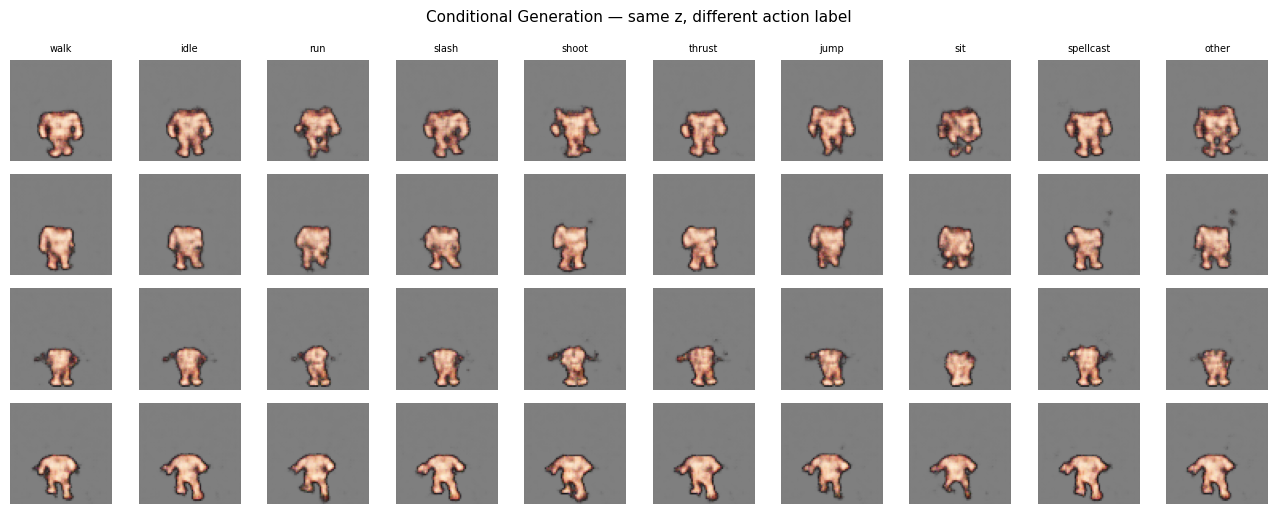

In [9]:
N_ROWS = 4
torch.manual_seed(0)
z_samples = torch.randn(N_ROWS, LATENT_DIM).to(DEVICE)

model.eval()
fig, axes = plt.subplots(N_ROWS, NUM_CLASSES, figsize=(NUM_CLASSES * 1.3, N_ROWS * 1.3))

with torch.no_grad():
    for row in range(N_ROWS):
        for col in range(NUM_CLASSES):
            c   = F.one_hot(torch.tensor([col]), NUM_CLASSES).float().to(DEVICE)
            img = model.decoder(z_samples[row].unsqueeze(0), c)
            img = img[0].cpu().permute(1, 2, 0).numpy()
            axes[row, col].imshow(composite(img))
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(LABEL_NAMES[col], fontsize=7)

plt.suptitle('Conditional Generation — same z, different action label', fontsize=11)
plt.tight_layout()
plt.show()